In [ ]:
!pip install tslearn
from tslearn.clustering import silhouette_score
from sklearn.decomposition import PCA

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [25, 8]

from tslearn.clustering import TimeSeriesKMeans
from tslearn.datasets import CachedDatasets
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
import pandas as pd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.9/389.9 kB 1.3 MB/s eta 0:00:00


In [ ]:
!unzip '/content/drive/MyDrive/Blur study data.zip'
!unzip '/content/drive/MyDrive/Blur study data2.zip'

Archive:  /content/drive/MyDrive/Blur study data.zip
   creating: Blur study data/
  inflating: Blur study data/all_participants_combined.csv  
   creating: Blur study data/Participant_1/
  inflating: Blur study data/Participant_1/baseline_ECG_data_participant1.csv  
  inflating: Blur study data/Participant_1/baseline_GSR_data_participant1.csv  
  inflating: Blur study data/Participant_1/feedback_part.csv  
  inflating: Blur study data/Participant_1/Filtered_ECG_512Hz.csv  
  inflating: Blur study data/Participant_1/Filtered_GSR_PPG.csv  
  inflating: Blur study data/Participant_1/labeled_ECG_data_participant1.csv  
  inflating: Blur study data/Participant_1/labeled_eye_data_participant1.csv  
  inflating: Blur study data/Participant_1/labeled_GSR_data_participant1.csv  
  inflating: Blur study data/Participant_1/labeled_head_data_participant1.csv  
  inflating: Blur study data/Participant_1/merged_labeled_data_participant1.csv  
  inflating: Blur study data/Participant_1/merged_resamp

In [ ]:
from scipy.signal import resample
import pandas as pd
import os
from datetime import timedelta


from scipy.signal import resample
import pandas as pd
from datetime import timedelta

def resample_ecg_data(df, original_rate, target_rate=250):
    if 'Timestamp' not in df.columns:
        raise ValueError("Timestamp column is required to regenerate timestamps.")

    start_time = pd.to_datetime(df['Timestamp'].iloc[0])

    # Mode-preserved columns
    preserve_cols = {}
    for col in ['FMS', 'Condition']:
        if col in df.columns:
            preserve_cols[col] = df[col].mode().iloc[0]

    # Select numeric signal columns only (excluding mode-preserved columns if numeric)
    signal_df = df.select_dtypes(include='number').copy()
    for col in preserve_cols:
        if col in signal_df.columns:
            signal_df.drop(columns=col, inplace=True)

    # Resample signal
    num_original_samples = len(signal_df)
    num_target_samples = int(num_original_samples * target_rate / original_rate)
    resampled_array = resample(signal_df.values, num_target_samples, axis=0)
    resampled_df = pd.DataFrame(resampled_array, columns=signal_df.columns)

    # Add preserved columns with constant mode value
    for col, mode_val in preserve_cols.items():
        resampled_df[col] = mode_val

    # Reconstruct timestamps
    interval = 1 / target_rate
    resampled_timestamps = [start_time + timedelta(seconds=i * interval) for i in range(num_target_samples)]
    resampled_df['Timestamp'] = resampled_timestamps

    return resampled_df



def load_participant_data(base_path, participant_ids, subfolder_prefix, filename_prefix, resample_ecg=False, original_rate=None):
    all_data = []

    for pid in participant_ids:
        file_path = os.path.join(base_path, f"{subfolder_prefix}{pid}", f"{filename_prefix}{pid}.csv")

        try:
            df = pd.read_csv(file_path)

            print(f"[Participant {pid}] Missing values:\n", df.isna().sum())
            df.dropna(inplace=True)

            if resample_ecg:
                if original_rate is None:
                    raise ValueError("Original sampling rate must be provided for ECG resampling.")
                df = resample_ecg_data(df, original_rate)
            df['participant'] = pid
            all_data.append(df)

        except FileNotFoundError:
            print(f"File not found for participant {pid}: {file_path}")
        except pd.errors.EmptyDataError:
            print(f"Empty or invalid file for participant {pid}: {file_path}")

    return pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()

base_path = r'/content/Blur study data'

participant_ids_train = range(1, 16)
# participant_ids_test = range(13, 15)

# ECG
original_ecg_rate = 500
train_ecg_data1 = load_participant_data(
    base_path,
    participant_ids_train,
    "Participant_",
    "labeled_ECG_data_participant",
    resample_ecg=True,
    original_rate=original_ecg_rate
)
# Eye Tracking
train_eye_data1 = load_participant_data(base_path, participant_ids_train, "Participant_", "labeled_eye_data_participant")
# test_eye_data = load_participant_data(base_path, participant_ids_test, "Participant_", "labeled_eye_participant")

# Head Tracking
train_head_data1 = load_participant_data(base_path, participant_ids_train, "Participant_", "labeled_head_data_participant")
# test_head_data = load_participant_data(base_path, participant_ids_test, "Participant_", "labeled_head_data_participant")

# GSR (Galvanic Skin Response)
train_gsr_data1 = load_participant_data(base_path, participant_ids_train, "Participant_", "labeled_GSR_data_participant")
# test_gsr_data = load_participant_data(base_path, participant_ids_test, "Participant_", "labeled_GSR_data_participant")



/tmp/ipython-input-533585653.py:55: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


[Participant 1] Missing values:
 Timestamp                           0
ECG_test1_ECGtoHR_LA_RA_CAL         0
Lead I (LA-RA)                      0
Lead II (LL-LA)                     0
Lead III (LL-RA)                    0
Vx-RL                               0
FMS                            612197
Condition                      612197
dtype: int64


/tmp/ipython-input-533585653.py:55: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


[Participant 2] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 639427
Condition           623555
dtype: int64


/tmp/ipython-input-533585653.py:55: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


...

[Participant 11] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 531434
Condition           531434
dtype: int64


/tmp/ipython-input-533585653.py:55: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


[Participant 12] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 333389
Condition           333389
dtype: int64


/tmp/ipython-input-533585653.py:55: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


[Participant 13] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 389276
Condition           389276
dtype: int64
[Participant 14] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 263714
Condition           263714
dtype: int64
[Participant 15] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 245756
Condition           245756
dtype: int64
[Participant 1] Missing values:
 timestamp                               0
LeftEye_Openness_Openness               0
RightEye_Openness_Openness              0
LeftEye_PupilDilation_PupilDilation     0
RightEye_PupilDilation_PupilDilation    0
LeftEye_PupilPosition_X                 0
LeftEye

In [ ]:
from scipy.signal import resample
import pandas as pd
from datetime import timedelta
import os

def resample_ecg_data(df, original_rate, target_rate=250):
    if 'Timestamp' not in df.columns:
        raise ValueError("Timestamp column is required to regenerate timestamps.")

    start_time = pd.to_datetime(df['Timestamp'].iloc[0])

    # Mode-preserved columns
    preserve_cols = {}
    for col in ['FMSQ', 'Condition']:
        if col in df.columns:
            preserve_cols[col] = df[col].mode().iloc[0]

    # Select numeric signal columns only (excluding mode-preserved columns if numeric)
    signal_df = df.select_dtypes(include='number').copy()
    for col in preserve_cols:
        if col in signal_df.columns:
            signal_df.drop(columns=col, inplace=True)

    # Resample signal
    num_original_samples = len(signal_df)
    num_target_samples = int(num_original_samples * target_rate / original_rate)
    resampled_array = resample(signal_df.values, num_target_samples, axis=0)
    resampled_df = pd.DataFrame(resampled_array, columns=signal_df.columns)

    # Add preserved columns with constant mode value
    for col, mode_val in preserve_cols.items():
        resampled_df[col] = mode_val

    # Reconstruct timestamps
    interval = 1 / target_rate
    resampled_timestamps = [start_time + timedelta(seconds=i * interval) for i in range(num_target_samples)]
    resampled_df['Timestamp'] = resampled_timestamps

    return resampled_df



def load_participant_data(base_path, participant_ids, subfolder_prefix, filename_prefix, resample_ecg=False, original_rate=None):
    all_data = []

    for pid in participant_ids:
        file_path = os.path.join(base_path, f"{subfolder_prefix}{pid}", f"{filename_prefix}{pid}.csv")

        try:
            df = pd.read_csv(file_path)

            print(f"[Participant {pid}] Missing values:\n", df.isna().sum())
            df.dropna(inplace=True)

            if resample_ecg:
                if original_rate is None:
                    raise ValueError("Original sampling rate must be provided for ECG resampling.")
                df = resample_ecg_data(df, original_rate)
            df['participant'] = pid
            all_data.append(df)

        except FileNotFoundError:
            print(f"File not found for participant {pid}: {file_path}")
        except pd.errors.EmptyDataError:
            print(f"Empty or invalid file for participant {pid}: {file_path}")

    return pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()

base_path = r'/content/Blur study data2'

participant_ids_train = range(2, 15)
# participant_ids_test = range(13, 15)

# ECG
original_ecg_rate = 500
train_ecg_data2 = load_participant_data(
    base_path,
    participant_ids_train,
    "Participant_",
    "labeled_ECG_data_participant",
    resample_ecg=True,
    original_rate=original_ecg_rate
)
# Eye Tracking
train_eye_data2 = load_participant_data(base_path, participant_ids_train, "Participant_", "labeled_eye_data_participant")
# test_eye_data = load_participant_data(base_path, participant_ids_test, "Participant_", "labeled_eye_participant")

# Head Tracking
train_head_data2 = load_participant_data(base_path, participant_ids_train, "Participant_", "labeled_head_data_participant")
# test_head_data = load_participant_data(base_path, participant_ids_test, "Participant_", "labeled_head_data_participant")

# GSR (Galvanic Skin Response)
train_gsr_data2 = load_participant_data(base_path, participant_ids_train, "Participant_", "labeled_GSR_data_participant")
# test_gsr_data = load_participant_data(base_path, participant_ids_test, "Participant_", "labeled_GSR_data_participant")



[Participant 2] Missing values:
 Timestamp                      0
ECG_test1_ECGtoHR_LA_RA_CAL    0
Lead I (LA-RA)                 0
Lead II (LL-LA)                0
Lead III (LL-RA)               0
Vx-RL                          0
FMSQ                           0
dtype: int64
[Participant 3] Missing values:
 Timestamp                          0
ECG_test1_ECGtoHR_LA_RA_CAL        0
Lead I (LA-RA)                     0
Lead II (LL-LA)                    0
Lead III (LL-RA)                   0
Vx-RL                              0
FMSQ                           36075
dtype: int64
[Participant 4] Missing values:
 Timestamp                      0
ECG_test1_ECGtoHR_LA_RA_CAL    0
Lead I (LA-RA)                 0
Lead II (LL-LA)                0
Lead III (LL-RA)               0
Vx-RL                          0
FMSQ                           0
dtype: int64
[Participant 5] Missing values:
 Timestamp                           0
ECG_test1_ECGtoHR_LA_RA_CAL         0
Lead I (LA-RA)                  

/tmp/ipython-input-342520433.py:50: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


[Participant 8] Missing values:
 Timestamp                      0
ECG_test1_ECGtoHR_LA_RA_CAL    0
Lead I (LA-RA)                 0
Lead II (LL-LA)                0
Lead III (LL-RA)               0
Vx-RL                          0
FMSQ                           0
dtype: int64
[Participant 9] Missing values:
 Timestamp                      0
ECG_test1_ECGtoHR_LA_RA_CAL    0
Lead I (LA-RA)                 0
Lead II (LL-LA)                0
Lead III (LL-RA)               0
Vx-RL                          0
FMSQ                           0
dtype: int64
[Participant 10] Missing values:
 Timestamp                      0
ECG_test1_ECGtoHR_LA_RA_CAL    0
Lead I (LA-RA)                 0
Lead II (LL-LA)                0
Lead III (LL-RA)               0
Vx-RL                          0
FMSQ                           0
dtype: int64
[Participant 11] Missing values:
 Timestamp                          0
ECG_test1_ECGtoHR_LA_RA_CAL        0
Lead I (LA-RA)                     0
Lead II (LL-LA)        

/tmp/ipython-input-342520433.py:50: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


[Participant 8] Missing values:
 timestamp                               0
LeftEye_Openness_Openness               0
RightEye_Openness_Openness              0
LeftEye_PupilDilation_PupilDilation     0
RightEye_PupilDilation_PupilDilation    0
LeftEye_PupilPosition_X                 0
LeftEye_PupilPosition_Y                 0
RightEye_PupilPosition_X                0
RightEye_PupilPosition_Y                0
LeftEye_Gaze_X                          0
LeftEye_Gaze_Y                          0
LeftEye_Gaze_Z                          0
RightEye_Gaze_X                         0
RightEye_Gaze_Y                         0
RightEye_Gaze_Z                         0
FMSQ                                    0
dtype: int64
[Participant 9] Missing values:
 timestamp                               0
LeftEye_Openness_Openness               0
RightEye_Openness_Openness              0
LeftEye_PupilDilation_PupilDilation     0
RightEye_PupilDilation_PupilDilation    0
LeftEye_PupilPosition_X                

In [ ]:
def load_participant_data(
    base_path, participant_ids, subfolder_prefix, filename_prefix,
    resample_ecg=False, original_rate=None, auto_detect_sampling=False
):
    all_data = []

    for pid in participant_ids:
        file_path = os.path.join(base_path, f"{subfolder_prefix}{pid}", f"{filename_prefix}{pid}.csv")

        try:
            df = pd.read_csv(file_path)

            print(f"[Participant {pid}] Missing values:\n", df.isna().sum())
            df.dropna(inplace=True)
            if df.empty:
                print(f"Empty DataFrame for participant {pid}: {file_path}")
                continue

            if resample_ecg:
                # Only resample if auto_detect_sampling is enabled and actual rate is different
                if auto_detect_sampling:
                    timestamps = pd.to_datetime(df["Timestamp"])
                    # Compute actual rate (based on median interval)
                    actual_interval = (timestamps.diff().dt.total_seconds().median())
                    actual_rate = round(1 / actual_interval) if actual_interval else None
                    print(f"[Participant {pid}] Detected ECG rate: {actual_rate} Hz")

                    if actual_rate and actual_rate != 250:
                        df = resample_ecg_data(df, actual_rate)
                else:
                    if original_rate is None:
                        raise ValueError("Original sampling rate must be provided for ECG resampling.")
                    df = resample_ecg_data(df, original_rate)

            df['participant'] = pid
            all_data.append(df)

        except FileNotFoundError:
            print(f"File not found for participant {pid}: {file_path}")
        except pd.errors.EmptyDataError:
            print(f"Empty or invalid file for participant {pid}: {file_path}")

    return pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()
def resample_ecg_data(df, original_rate, target_rate=250):
    if 'Timestamp' not in df.columns:
        raise ValueError("Timestamp column is required to regenerate timestamps.")

    start_time = pd.to_datetime(df['Timestamp'].iloc[0])

    # Mode-preserved columns
    preserve_cols = {}
    for col in ['FMS', 'Condition']:
        if col in df.columns:
            preserve_cols[col] = df[col].mode().iloc[0]

    # Select numeric signal columns only (excluding mode-preserved columns if numeric)
    signal_df = df.select_dtypes(include='number').copy()
    for col in preserve_cols:
        if col in signal_df.columns:
            signal_df.drop(columns=col, inplace=True)

    # Resample signal
    num_original_samples = len(signal_df)
    num_target_samples = int(num_original_samples * target_rate / original_rate)
    resampled_array = resample(signal_df.values, num_target_samples, axis=0)
    resampled_df = pd.DataFrame(resampled_array, columns=signal_df.columns)

    # Add preserved columns with constant mode value
    for col, mode_val in preserve_cols.items():
        resampled_df[col] = mode_val

    # Reconstruct timestamps
    interval = 1 / target_rate
    resampled_timestamps = [start_time + timedelta(seconds=i * interval) for i in range(num_target_samples)]
    resampled_df['Timestamp'] = resampled_timestamps

    return resampled_df
participant_ids_dataset3 = range(1, 16)
base_path='/content/drive/MyDrive/CyberSense/User Study/User Study Data/Processed data'
# ECG: Let the loader detect which files to resample
train_ecg_data3 = load_participant_data(
    base_path,
    participant_ids_dataset3,
    "Participant_",
    "labeled_ECG_data_participant",
    resample_ecg=True,
    auto_detect_sampling=True  # Automatically detects sampling rate
)

# Other signals (already 250 Hz)
#train_eye_data3 = load_participant_data(base_path, participant_ids_dataset3, "Participant_", "labeled_eye_data_participant")
train_head_data3 = load_participant_data(base_path, participant_ids_dataset3, "Participant_", "labeled_head_data_participant")
train_gsr_data3 = load_participant_data(base_path, participant_ids_dataset3, "Participant_", "labeled_GSR_data_participant")


[Participant 1] Missing values:
 Timestamp               0
Lead I (LA-RA)          0
Lead II (LL-LA)         0
Lead III (LL-RA)        0
Vx-RL                   0
FMS                 33772
Condition            2740
dtype: int64
[Participant 1] Detected ECG rate: 500 Hz


/tmp/ipython-input-3420040596.py:11: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


[Participant 2] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 309530
Condition           309530
dtype: int64
[Participant 2] Detected ECG rate: 250 Hz


/tmp/ipython-input-3420040596.py:11: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


[Participant 3] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 306289
Condition           306289
dtype: int64
[Participant 3] Detected ECG rate: 250 Hz
[Participant 4] Missing values:
 Timestamp              0
Lead I (LA-RA)         0
Lead II (LL-LA)        0
Lead III (LL-RA)       0
Vx-RL                  0
FMS                 8411
Condition           8411
dtype: int64
[Participant 4] Detected ECG rate: 250 Hz
[Participant 5] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 213455
Condition           213455
dtype: int64
[Participant 5] Detected ECG rate: 250 Hz
[Participant 6] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS            

/tmp/ipython-input-3420040596.py:11: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


[Participant 9] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 305490
Condition           305490
dtype: int64
[Participant 9] Detected ECG rate: 250 Hz
[Participant 10] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 417179
Condition           417179
dtype: int64
[Participant 10] Detected ECG rate: 250 Hz
[Participant 11] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 231889
Condition           231889
dtype: int64
[Participant 11] Detected ECG rate: 250 Hz
[Participant 12] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                  

/tmp/ipython-input-3420040596.py:11: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


[Participant 15] Missing values:
 Timestamp                0
Lead I (LA-RA)           0
Lead II (LL-LA)          0
Lead III (LL-RA)         0
Vx-RL                    0
FMS                 244027
Condition           236094
dtype: int64
[Participant 15] Detected ECG rate: 250 Hz
[Participant 1] Missing values:
 Time              0
#Frame            0
HeadQRotationX    0
HeadQRotationY    0
HeadQRotationZ    0
HeadQRotationW    0
HeadEulX          0
HeadEulY          0
HeadEulZ          0
FMS               0
Condition         0
dtype: int64
[Participant 2] Missing values:
 Time              0
#Frame            0
HeadQRotationX    0
HeadQRotationY    0
HeadQRotationZ    0
HeadQRotationW    0
HeadEulX          0
HeadEulY          0
HeadEulZ          0
FMS               0
Condition         0
dtype: int64
[Participant 3] Missing values:
 Time              0
#Frame            0
HeadQRotationX    0
HeadQRotationY    0
HeadQRotationZ    0
HeadQRotationW    0
HeadEulX          0
HeadEulY        

In [ ]:
id_offset = train_ecg_data1['participant'].max()

train_eye_data2['participant'] += id_offset
train_head_data2['participant'] += id_offset
train_gsr_data2['participant'] += id_offset
train_ecg_data2['participant'] += id_offset

id_offset = train_ecg_data2['participant'].max()
# train_eye_data3['participant'] += id_offset
train_head_data3['participant'] += id_offset
train_ecg_data3['participant'] += id_offset
train_gsr_data3['participant'] += id_offset
print(np.unique(train_ecg_data1['participant']),np.unique(train_ecg_data2['participant']),np.unique(train_ecg_data3['participant']))



[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15] [17 18 19 20 21 22 23 24 25 26 27 28 29] [30 31 32 33 34 35 38 39 40 41 42 43 44]


In [ ]:
train_ecg_data2.rename(columns={'FMSQ': 'FMS'}, inplace=True)
train_gsr_data2.rename(columns={'FMSQ': 'FMS'}, inplace=True)
train_eye_data2.rename(columns={'FMSQ': 'FMS'}, inplace=True)
train_head_data2.rename(columns={'FMSQ': 'FMS'}, inplace=True)

all_data_gsr = pd.concat([train_gsr_data1, train_gsr_data2, train_gsr_data3], ignore_index=True)
all_data_ecg = pd.concat([train_ecg_data1, train_ecg_data2, train_ecg_data3], ignore_index=True)

all_data_gsr['FMS'] = (
    all_data_gsr['FMS']
    .astype(str)
    .str.replace('*', '', regex=False)  # remove asterisk
    .str.strip()
)
all_data_ecg['FMS']=(all_data_ecg['FMS']
    .astype(str)
    .str.replace('*', '', regex=False)  # remove asterisk
    .str.strip()
)
all_data_ecg['FMS']=pd.to_numeric(all_data_ecg['FMS'], errors='coerce')


all_data_gsr['FMS'] = pd.to_numeric(all_data_gsr['FMS'], errors='coerce')
all_data_gsr

,Timestamp,GSR_Filtered,PPG_Filtered,FMS,Condition,participant
0,2025-04-04 16:56:03.759,0.001744,123.558662,4.0,NB,1
1,2025-04-04 16:56:03.778,0.003374,191.259492,4.0,NB,1
2,2025-04-04 16:56:03.798,0.004946,241.255469,4.0,NB,1
3,2025-04-04 16:56:03.817,0.006283,261.810151,4.0,NB,1
4,2025-04-04 16:56:03.837,0.007244,245.547978,4.0,NB,1
...,...,...,...,...,...,...
2284607,2025-06-25 18:37:49.074,-0.000104,-1.919787,5.0,NB,44
2284608,2025-06-25 18:37:49.081,-0.000182,-3.024155,5.0,NB,44
2284609,2025-06-25 18:37:49.089,-0.000261,-4.156642,5.0,NB,44
2284610,2025-06-25 18:37:49.097,-0.000341,-5.299112,5.0,NB,44


In [ ]:
all_data_ecg

,ECG_test1_ECGtoHR_LA_RA_CAL,Lead I (LA-RA),Lead II (LL-LA),Lead III (LL-RA),Vx-RL,FMS,Condition,Timestamp,participant
0,85.872499,-0.066876,-0.057075,-0.123950,0.006850,4.500024,MB,2025-04-04 16:56:02.743000,1
1,85.191710,-0.069999,-0.044142,-0.114141,0.007221,3.863356,MB,2025-04-04 16:56:02.747000,1
2,85.408186,-0.069164,-0.024283,-0.093447,-0.008102,4.075611,MB,2025-04-04 16:56:02.751000,1
3,85.284574,-0.067063,-0.017088,-0.084151,-0.015187,3.948239,MB,2025-04-04 16:56:02.755000,1
4,85.368384,-0.065067,-0.014753,-0.079820,-0.013862,4.039233,MB,2025-04-04 16:56:02.759000,1
...,...,...,...,...,...,...,...,...,...
4679113,NaN,-0.072107,0.127933,0.055826,-0.174796,5.000000,NB,2025-06-25 18:37:49.091,44
4679114,NaN,-0.079731,0.134851,0.055121,-0.168986,5.000000,NB,2025-06-25 18:37:49.095,44
4679115,NaN,-0.091567,0.145087,0.053520,-0.160686,5.000000,NB,2025-06-25 18:37:49.099,44
4679116,NaN,-0.098998,0.156676,0.057677,-0.150513,5.000000,NB,2025-06-25 18:37:49.103,44


Autoencoder

In [ ]:
from __future__ import print_function
import numpy as np
import h5py
import glob
import math
import os
import shutil
from scipy import signal
from scipy.signal import butter, lfilter
from keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D, Conv1D, MaxPooling1D, UpSampling1D, Flatten, Dropout, Reshape
from keras.layers import Bidirectional, BatchNormalization, ZeroPadding1D, Conv2DTranspose
from keras.models import Model
from tensorflow.keras import backend as K
from keras.optimizers import SGD, Adam
from keras import regularizers

from keras.callbacks import ModelCheckpoint, LearningRateScheduler, ReduceLROnPlateau, EarlyStopping
from keras.initializers import VarianceScaling
from keras.callbacks import CSVLogger

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
from matplotlib.pyplot import savefig

import seaborn as sns
sns.set_style('darkgrid')
sns.set_palette('muted')

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D, Flatten, Reshape
from tensorflow.keras import backend as K

inp = Input(shape=(500, 1))

# Encoder
e = Conv1D(8, 3, activation='tanh', padding='same')(inp)       # (500, 8)
e = MaxPooling1D(2, padding='same')(e)                         # (250, 8)
e = Conv1D(4, 3, activation='tanh', padding='same')(e)         # (250, 4)
e = MaxPooling1D(2, padding='same')(e)                         # (125, 4)
e = Conv1D(2, 3, activation='tanh', padding='same')(e)         # (125, 2)
e = MaxPooling1D(5, padding='same')(e)                         # (25, 2)

shape_before_flattening = K.int_shape(e)
encoded = Flatten()(e)                                         # (25*2=50,)

# Decoder
d = Reshape(shape_before_flattening[1:])(encoded)              # (25, 2)
d = Conv1D(2, 3, activation='tanh', padding='same')(d)
d = UpSampling1D(5)(d)                                         # (125, 2)
d = Conv1D(4, 3, activation='tanh', padding='same')(d)
d = UpSampling1D(2)(d)                                         # (250, 4)
d = Conv1D(8, 3, activation='tanh', padding='same')(d)
d = UpSampling1D(2)(d)                                         # (500, 8)
decoded = Conv1D(1, 3, activation='linear', padding='same')(d) # (500, 1)

# Models
autoencoder = Model(inputs=inp, outputs=decoded, name='autoencoder')
encoder = Model(inputs=inp, outputs=encoded, name='encoder')

# Summary
autoencoder.summary()


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 500, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 500, 8)         │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 250, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 250, 4)         │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 125, 4)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 125, 2)         │            26 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 25, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 25, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 25, 2)          │            14 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_3 (UpSampling1D)  │ (None, 125, 2)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 125, 4)         │            28 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_4 (UpSampling1D)  │ (None, 250, 4)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_12 (Conv1D)              │ (None, 250, 8)         │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_5 (UpSampling1D)  │ (None, 500, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 500, 1)         │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 329 (1.29 KB)

 Trainable params: 329 (1.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# -------------------- Segment Data into Windows --------------------
def segment_data(data, target, sequence_length):
    X, y = [], []
    for i in range(0, len(data) - sequence_length, sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(target[i + sequence_length])
    return np.array(X), np.array(y)

# -------------------- Preprocess Participant Data --------------------
def preprocess_data(df_all, target_col, sequence_length, feature_cols, scale_features=False):
    all_X, all_y = [], []

    for participant_id, df in df_all.groupby('participant'):
        df = df.dropna().reset_index(drop=True)

        if scale_features:
            scaler = MinMaxScaler()
            df[feature_cols] = scaler.fit_transform(df[feature_cols])

        features = df[feature_cols].values
        targets = df[target_col].values

        X, y = segment_data(features, targets, sequence_length)
        all_X.append(X)
        all_y.append(y)

    return np.concatenate(all_X, axis=0), np.concatenate(all_y, axis=0)

# -------------------- Parameters --------------------
sequence_length = 500  # 4 seconds at 125 Hz
feature_cols = ['GSR_Filtered']
target_col = 'participant'

all_X, all_y = [], []

# -------------------- Loop Through All 43 Participants --------------------
for i in range(1, 44):  # Participants 1 to 43
    try:
        simulation_df = all_data_gsr[all_data_gsr['participant'] == i]

        simulation_df.drop(columns=['FMS', 'Condition'], inplace=True, errors='ignore')
        simulation_df.dropna(inplace=True)
        simulation_df['participant'] = i  # Ensure participant column is correct


        X_sim, y_sim = preprocess_data(
            simulation_df,
            target_col=target_col,
            sequence_length=sequence_length,
            feature_cols=feature_cols,
            scale_features=True
        )

        all_X.append(X_sim)
        all_y.append(y_sim)

    except Exception as e:
        print(f"Error processing participant {i}: {e}")

# -------------------- Combine All Data --------------------
X_all = np.concatenate(all_X, axis=0)
y_all = np.concatenate(all_y, axis=0)
X_all.shape, y_all.shape

/tmp/ipython-input-4280253553.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simulation_df.drop(columns=['FMS', 'Condition'], inplace=True, errors='ignore')
/tmp/ipython-input-4280253553.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simulation_df.dropna(inplace=True)
/tmp/ipython-input-4280253553.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simulation_df['par

Error processing participant 15: need at least one array to concatenate
Error processing participant 16: need at least one array to concatenate


/tmp/ipython-input-4280253553.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simulation_df.drop(columns=['FMS', 'Condition'], inplace=True, errors='ignore')
/tmp/ipython-input-4280253553.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simulation_df.dropna(inplace=True)
/tmp/ipython-input-4280253553.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simulation_df['par

((4461, 500, 1), (4461,))

with GSR

In [ ]:
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(X_all, X_all, batch_size=128, epochs=50)

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 0.2643
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0122
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.0084
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 0.0071
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0059
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0047
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0035
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 0.0027
Epoch 9/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 0.0023
Epoch 10/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 0.0022
Epoch 11/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - loss: 0.0020
Epoch 12/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 0.0019
Epoch 13/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 0.0017
Epoch 14/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - loss: 0.0016
Epoch 15/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - lo

with extracted encoded features doing kmeans

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Silhouette Score: 0.5578


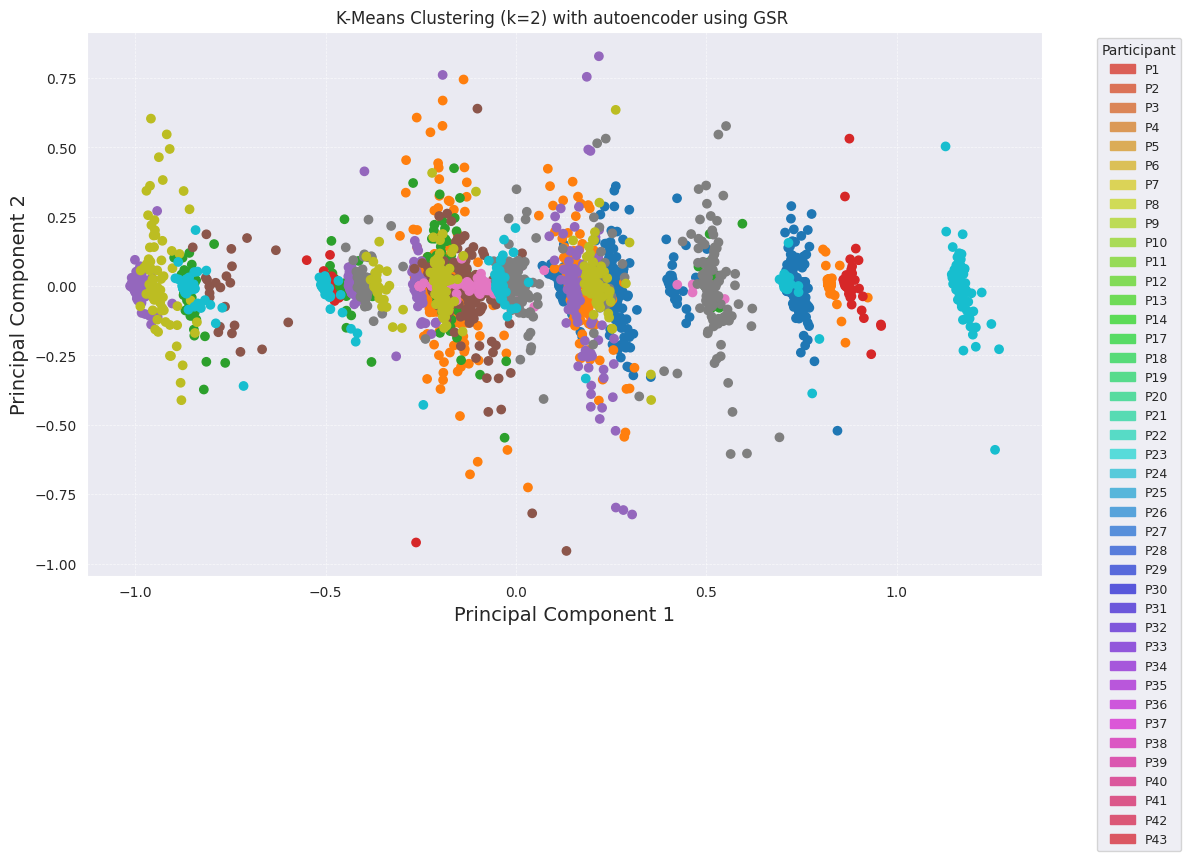


Silhouette Score: 0.5378


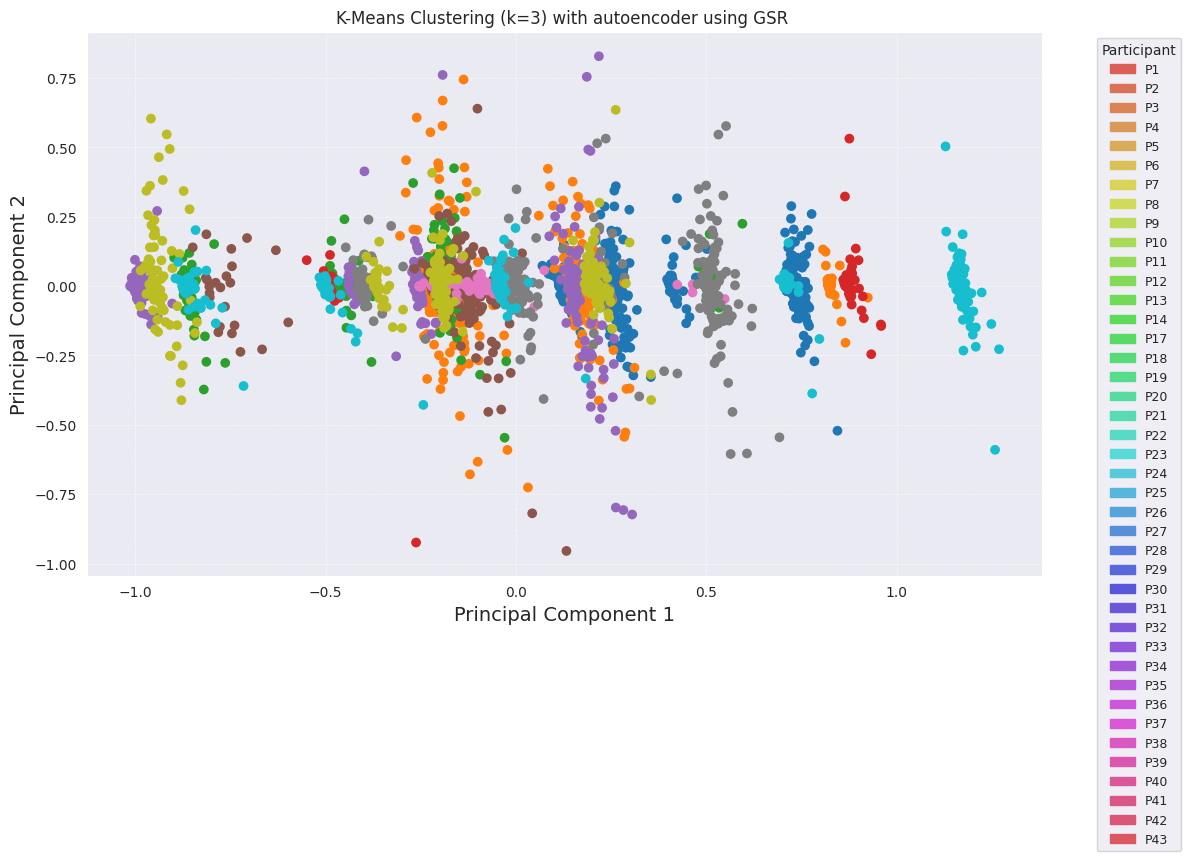


Silhouette Score: 0.5672


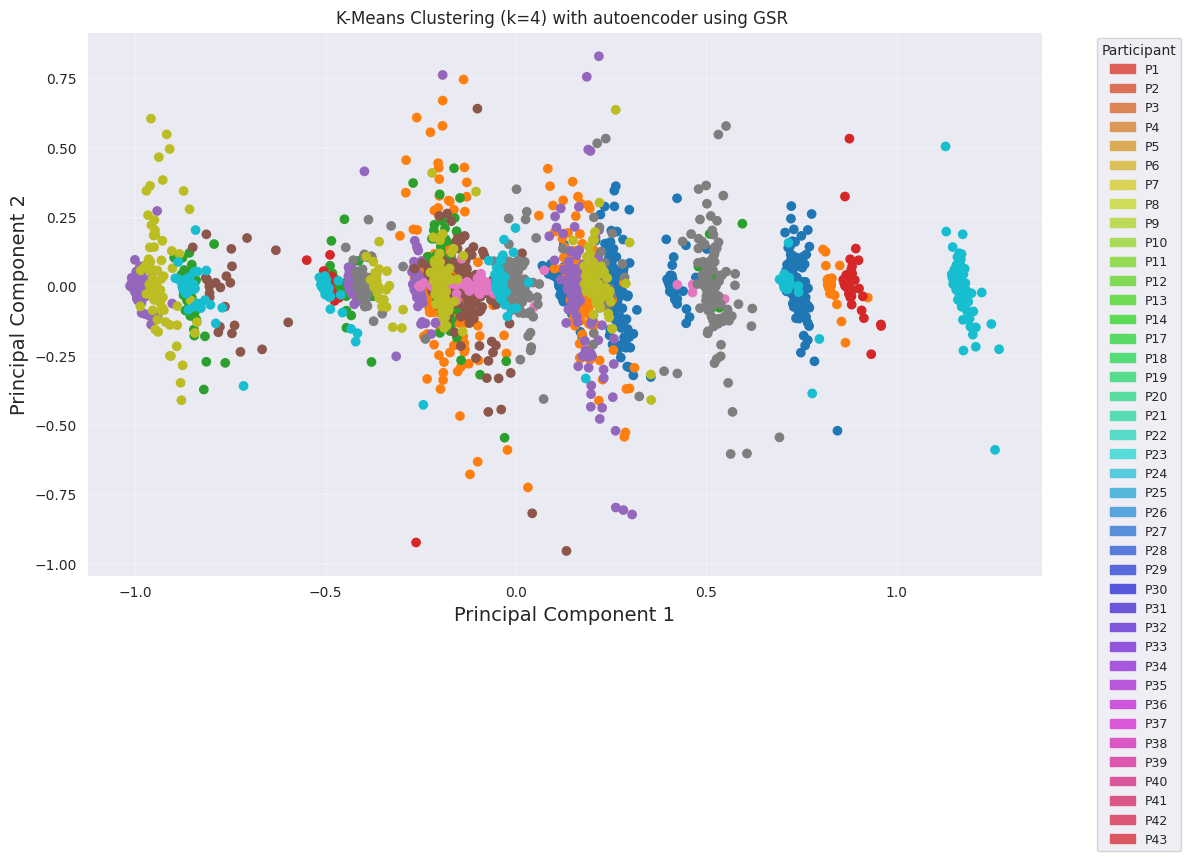


Silhouette Score: 0.5747


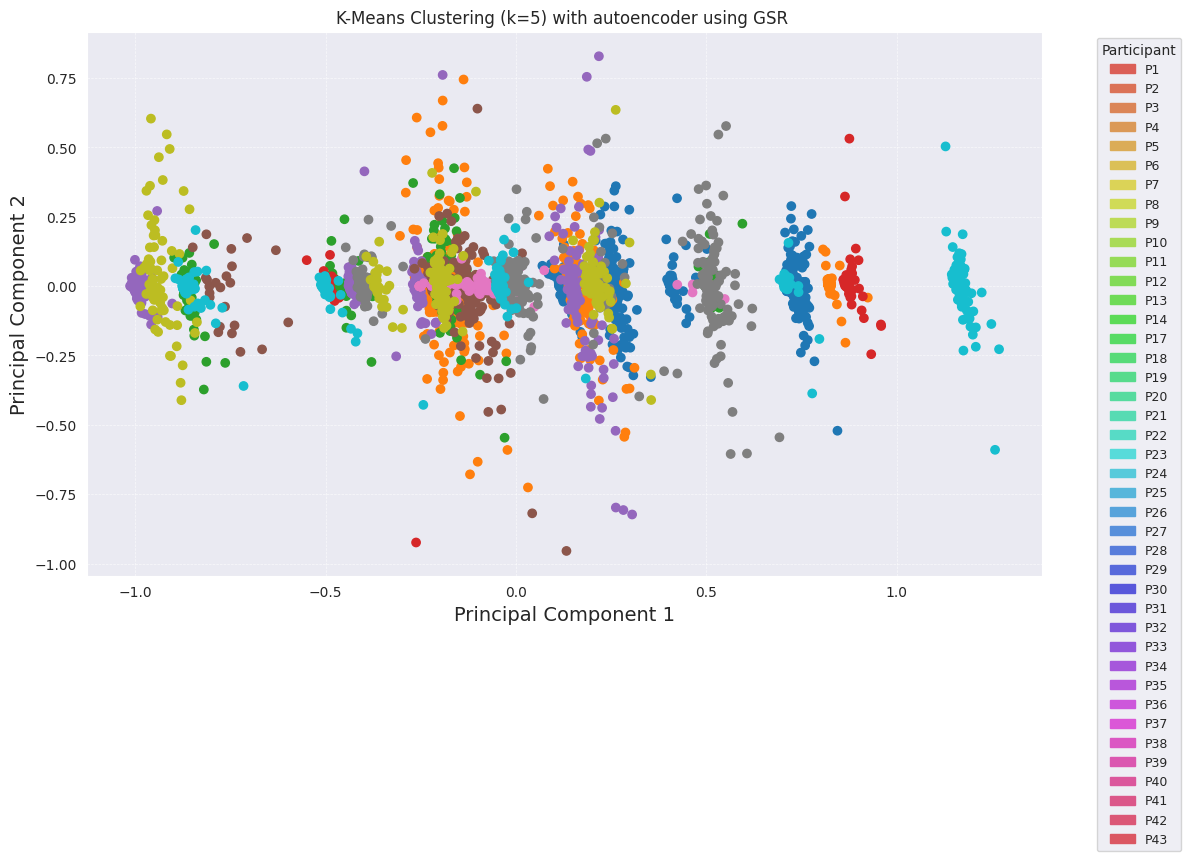


Silhouette Score: 0.5774


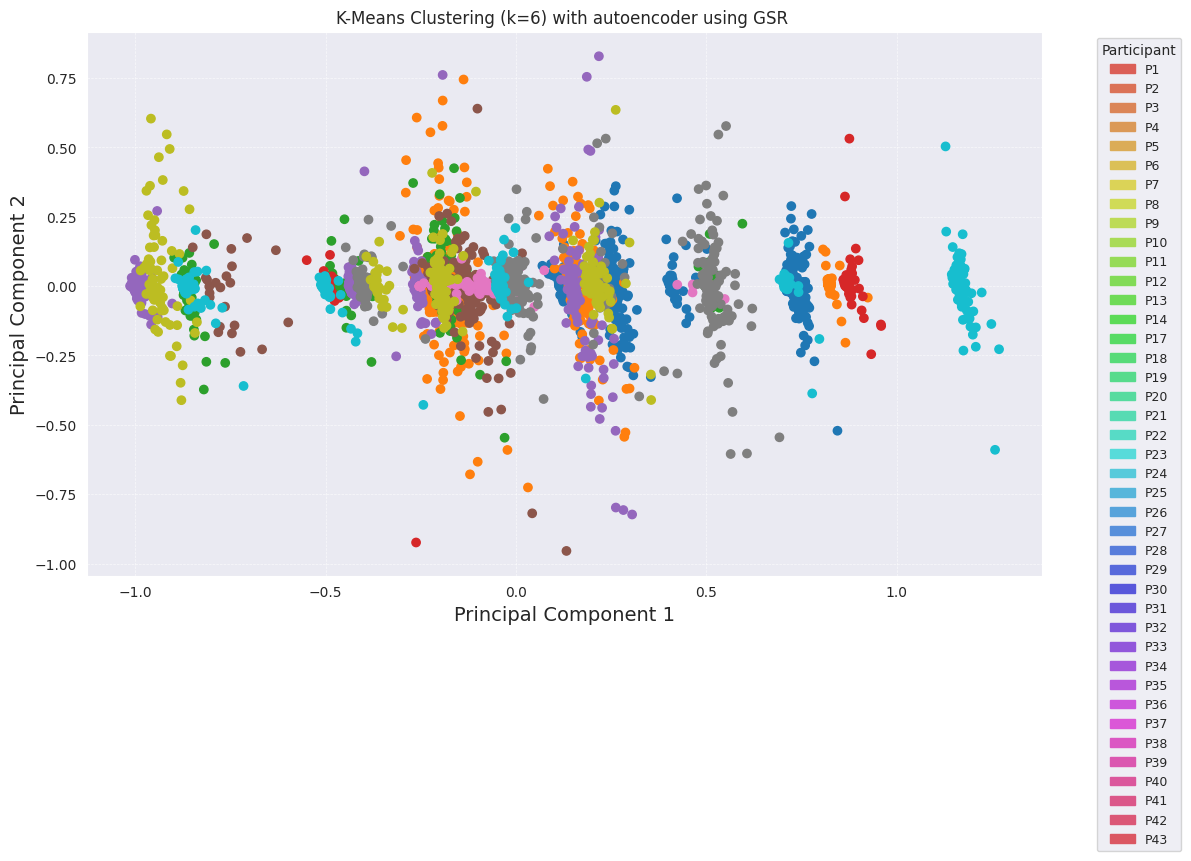

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

cluster_range = [2, 3, 4, 5, 6,7,8]
X_encoded = encoder.predict(X_all)
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, n_init=20)
    cluster_labels = kmeans.fit_predict(X_encoded)

    # Optional: reduce dimension for visualization
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X_encoded)
    sil_score = silhouette_score(X_2d, cluster_labels)
    print(f"\nSilhouette Score: {sil_score:.4f}")


    plt.figure(figsize=(12, 8))
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_all, cmap='tab10')
    plt.title(f"K-Means Clustering (k={k}) with autoencoder using GSR ")

    plt.xlabel('Principal Component 1', fontsize=14)
    plt.ylabel('Principal Component 2', fontsize=14)

# Legend: Manual for each participant
    unique_participants = np.unique(y_all)
    participant_labels = [f'P{int(pid)}' for pid in unique_participants]
    num_participants = len(np.unique(y_all))
    palette = sns.color_palette("hls", n_colors=num_participants)
    color_map = mcolors.ListedColormap(palette)
    handles = [Patch(color=color_map(i / num_participants), label=label)
           for i, label in enumerate(participant_labels)]

    plt.legend(handles=handles, title="Participant", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.show()


Table with diff k

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


pre_ssq = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/total_pre_ssq_scores.csv")
post_ssq = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/total_post_ssq_scores.csv")
participant_info = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/participant_info.csv")
participant_info = participant_info.rename(columns={'Participant': 'participant'})

# Merge pre and post SSQ on Participant, then merge with participant_info
metadata = pd.merge(pre_ssq, post_ssq, on="participant")
metadata = pd.merge(metadata, participant_info, on="participant")

# -------------------- Cluster Analysis with Multiple K --------------------
k_values = [2, 3, 4, 5, 6, 7]
summary_tables = {}
X_encoded = encoder.predict(X_all)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=4)
    clusters = kmeans.fit_predict(X_encoded)
    sil_score = silhouette_score(X_encoded, clusters)
    print(f"K = {k}, Silhouette Score: {sil_score:.4f}")

    # Create cluster DataFrame
    df_cluster = pd.DataFrame({"cluster": clusters, "participant": y_all})

    # Merge with metadata
    df_merged = df_cluster.merge(metadata, on="participant")

    # Group by cluster and summarize
    summary = df_merged.groupby("cluster").agg(
        Number=("participant", "count"),
        pre_nausea=("Nausea", "mean"),
        pre_oculomotor=("Oculomotor", "mean"),
        pre_disorientation=("Disorientation", "mean"),
        pre_total=("Total", "mean"),
        post_nausea=("post_nausea", "mean"),
        post_oculomotor=("post_oculomotor", "mean"),
        post_disorientation=("post_disorientation", "mean"),
        post_total=("post_total", "mean"),
        avg_age=("Age", "mean"),
        gender_distribution=("Gender", lambda x: x.value_counts().to_dict()),
        prior_experience=("Prev_VR_Experience", lambda x: x.value_counts().to_dict())
    ).reset_index()

    # Format group labels
    summary["Group"] = ["Group " + str(i + 1) for i in summary["cluster"]]
    summary = summary.round(2)

    # Store selected columns
    summary_tables[f'K={k}'] = summary[[
        "Group", "Number",
        "pre_nausea", "pre_oculomotor", "pre_disorientation", "pre_total",
        "post_nausea", "post_oculomotor", "post_disorientation", "post_total",
        "avg_age", "gender_distribution", "prior_experience"
    ]]


# -------------------- Display Summary Tables --------------------
for k, summary in summary_tables.items():
    print(f"\nSummary for {k}:\n")
    print(summary.to_string(index=False))



140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
K = 2, Silhouette Score: 0.4864
K = 3, Silhouette Score: 0.4043
K = 4, Silhouette Score: 0.4398
K = 5, Silhouette Score: 0.3793
K = 6, Silhouette Score: 0.3729
K = 7, Silhouette Score: 0.3794

Summary for K=2:

  Group  Number  pre_nausea  pre_oculomotor  pre_disorientation  pre_total  post_nausea  post_oculomotor  post_disorientation  post_total  avg_age           gender_distribution                                    prior_experience
Group 1    1920        5.06            7.02                6.39       7.17        22.28            24.88                33.91       30.12    25.73 {'Female': 1356, 'Male': 564}   {'Rarely': 1001, 'Never': 781, 'Frequently': 138}
Group 2    2541        9.99           12.87               10.99      13.22        22.29            25.16                26.79       28.35    24.85 {'Male': 1743, 'Female': 798} {'Never': 1571, 'Rarely': 863, 'Occasionally': 107}

Summary for K=3:

  Group  Number  pre_nausea  pre_oculomoto

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load metadata
pre_ssq = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/total_pre_ssq_scores.csv")
post_ssq = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/total_post_ssq_scores.csv")
participant_info = pd.read_csv("/content/drive/MyDrive/CyberSense/User Study/SSQ/participant_info.csv")
participant_info = participant_info.rename(columns={'Participant': 'participant'})

# Merge all metadata
metadata = pd.merge(pre_ssq, post_ssq, on="participant")
metadata = pd.merge(metadata, participant_info, on="participant")
metadata["participant"] = metadata["participant"].astype(str)

# Predict embeddings from encoder
X_encoded = encoder.predict(X_all)

# Clustering and summarization
k_values = [2, 3, 4, 5, 6, 7]
summary_tables = {}

for k in k_values:
    print(f"\n--- Clustering with K = {k} ---")

    # KMeans clustering
    kmeans = KMeans(n_clusters=k, random_state=4)
    clusters = kmeans.fit_predict(X_encoded)
    sil_score = silhouette_score(X_encoded, clusters)
    print(f"Silhouette Score: {sil_score:.4f}")

    # DataFrame of participant-level cluster assignments
    df_cluster = pd.DataFrame({
        "cluster": clusters,
        "participant": y_all
    }).drop_duplicates("participant")  # One row per participant
    df_cluster["participant"] = df_cluster["participant"].astype(str)

    # Merge with metadata
    df_merged = df_cluster.merge(metadata, on="participant")

    # Group-wise summary
    summary = df_merged.groupby("cluster").agg(
        Number_of_participants=("participant", "nunique"),
        pre_nausea=("Nausea", "mean"),
        pre_oculomotor=("Oculomotor", "mean"),
        pre_disorientation=("Disorientation", "mean"),
        pre_total=("Total", "mean"),
        post_nausea=("post_nausea", "mean"),
        post_oculomotor=("post_oculomotor", "mean"),
        avg_age=("Age", "mean"),
        gender_distribution=("Gender", lambda x: x.value_counts().to_dict())
    ).reset_index()

    # Format group label
    summary["Group"] = "Group " + (summary["cluster"] + 1).astype(str)

    # Select & reorder columns
    summary = summary[[
        "Group", "Number_of_participants",
        "pre_nausea", "pre_oculomotor", "pre_disorientation", "pre_total",
        "post_nausea", "post_oculomotor", "avg_age", "gender_distribution"
    ]].round(2)

    # Store
    summary_tables[f'K={k}'] = summary

# -------------------- Display All Summary Tables --------------------
for k, summary in summary_tables.items():
    print(f"\n===== Summary Table for {k} =====\n")
    print(summary.to_string(index=False))


140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

--- Clustering with K = 2 ---
Silhouette Score: 0.4864

--- Clustering with K = 3 ---
Silhouette Score: 0.4043

--- Clustering with K = 4 ---
Silhouette Score: 0.4398

--- Clustering with K = 5 ---
Silhouette Score: 0.3793

--- Clustering with K = 6 ---
Silhouette Score: 0.3729

--- Clustering with K = 7 ---
Silhouette Score: 0.3794

===== Summary Table for K=2 =====

  Group  Number_of_participants  pre_nausea  pre_oculomotor  pre_disorientation  pre_total  post_nausea  post_oculomotor  avg_age       gender_distribution
Group 1                      16        6.26            9.48                6.67       8.92        23.25            28.27    25.69 {'Female': 11, 'Male': 5}
Group 2                      25       11.70           13.90               12.44      14.79        28.11            26.78    26.36 {'Male': 16, 'Female': 9}

===== Summary Table for K=3 =====

  Group  Number_of_participants  pre_nausea  pre_oculomotor  pre_disorientation  pr

In [ ]:
from scipy.stats import f_oneway, ttest_ind, chi2_contingency

# Define variables to test
continuous_vars = [
    "Nausea", "Oculomotor", "Disorientation", "Total",
    "post_nausea", "post_oculomotor", "post_disorientation", "post_total", "Age"
]
categorical_vars = ["Gender", "Prev_VR_Experience"]
# Convert all 'participant' columns to string
# pre_ssq["participant"] = pre_ssq["participant"].astype(str)
# post_ssq["participant"] = post_ssq["participant"].astype(str)
# participant_info["participant"] = participant_info["participant"].astype(str)
# y_all = y_all.astype(str)  # If you're using y_all in merges

# Perform significance testing for K = 2, 3, 4
for k in [2, 3, 4]:
    print(f"\n--- Statistical Tests for k = {k} ---")

    # Recreate clustering
    kmeans = KMeans(n_clusters=k, random_state=4)
    clusters = kmeans.fit_predict(X_encoded)
    df_cluster = pd.DataFrame({"participant": y_all, "cluster": clusters})
    df_cluster["participant"] = df_cluster["participant"].astype(str)
    metadata["participant"] = metadata["participant"].astype(str)
    df_merged = df_cluster.merge(metadata, on="participant")

    # --- Continuous Variables ---
    for col in continuous_vars:
        groups = [df_merged[df_merged["cluster"] == i][col] for i in range(k)]

        # Check that all groups have data
        if all(len(g) > 1 for g in groups):
            if k == 2:
                stat, p = ttest_ind(groups[0], groups[1])
                test_type = "T-test"
            else:
                stat, p = f_oneway(*groups)
                test_type = "ANOVA"

            if p < 0.05:
                print(f"{test_type} — {col}: p = {p:.4f} → Significant")
            else:
                print(f"{test_type} — {col}: p = {p:.4f} → Not significant")

    # --- Categorical Variables ---
    for col in categorical_vars:
        contingency = pd.crosstab(df_merged["cluster"], df_merged[col])
        if contingency.shape[0] == k and contingency.shape[1] > 1:
            chi2, p, dof, expected = chi2_contingency(contingency)
            if p < 0.05:
                print(f"Chi-square — {col}: p = {p:.4f} →  Significant")
            else:
                print(f"Chi-square — {col}: p = {p:.4f} → Not significant")



--- Statistical Tests for k = 2 ---
T-test — Nausea: p = 0.0000 → Significant
T-test — Oculomotor: p = 0.0000 → Significant
T-test — Disorientation: p = 0.0000 → Significant
T-test — Total: p = 0.0000 → Significant
T-test — post_nausea: p = 0.9911 → Not significant
T-test — post_oculomotor: p = 0.6879 → Not significant
T-test — post_disorientation: p = 0.0000 → Significant
T-test — post_total: p = 0.0547 → Not significant
T-test — Age: p = 0.0001 → Significant
Chi-square — Gender: p = 0.0000 →  Significant
Chi-square — Prev_VR_Experience: p = 0.0000 →  Significant

--- Statistical Tests for k = 3 ---
ANOVA — Nausea: p = 0.0000 → Significant
ANOVA — Oculomotor: p = 0.0000 → Significant
ANOVA — Disorientation: p = 0.0000 → Significant
ANOVA — Total: p = 0.0000 → Significant
ANOVA — post_nausea: p = 0.0000 → Significant
ANOVA — post_oculomotor: p = 0.0000 → Significant
ANOVA — post_disorientation: p = 0.0000 → Significant
ANOVA — post_total: p = 0.0000 → Significant
ANOVA — Age: p = 0.00